In [1]:
import pandas as pd
from itables import init_notebook_mode
import polars as pl
import os
import numpy as np
init_notebook_mode(all_interactive=True)
import polars.selectors as cs

import plotnine as pn



In [2]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

In [52]:
sa[sa["pid"] == "XFKKVM"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [29]:
# ---
# jupyter:
#   jupytext:
#     cell_metadata_filter: -all
#     formats: ipynb,py:percent
#     sync_on_save: true
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1
# ---

# %%
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
from itables import init_notebook_mode
import polars as pl
import os

# %%
init_notebook_mode(all_interactive=True)

# %%
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

# %%
from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *

# %%

somatic_snvs = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/somatic_snvs_vep_annotated.parquet")

sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")

fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
fr_res = pd.merge(fr_res, sa, left_on="sampleID", right_on="pid")
fr_res["Method"] = "FRASER"

fr_res = fr_res[fr_res["geneID_short"].isin(genes_of_interest["geneID_short"])]


fr_res = fr_res.merge(somatic_snvs[["somatic_snv_#Uploaded_variation", "sampleID", "MASTER_annotated_gene", "vep_Gene", "somatic_snv_IMPACT", "somatic_snv_Consequence", "somatic_snv_max_spliceai_score", "somatic_snv_am_pathogenicity", "somatic_snv_AbSplice2_max", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1"]] , left_on=["geneID_short", "sampleID"], right_on=["vep_Gene", "sampleID"], how="left")



gene_annot_pl = pl.from_pandas(gene_annot_dt[["gene_name", "geneID_short"]])

germline_snvs = (
    pl.scan_parquet(
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet"
    )
    # Apply all filters first to reduce data size
    .filter(
        (pl.col("sampleID").is_in(fr_res["sampleID"]))
    )
    # Perform the join within Polars using join_as_coerced
    .join(
        gene_annot_pl.lazy(), left_on="HUGO_Symbol", right_on="gene_name", how="inner"
    )
    .filter(pl.col("geneID_short").is_in(genes_of_interest["geneID_short"]))
    .head(10000)
    # Collect using the streaming engine and convert to Pandas
    .collect(engine="streaming")
    .to_pandas()
)


germline_snvs = germline_snvs.rename(columns={"#CHROM": "seqnames", "REF": "Ref", "ALT": "Alt"})
print(germline_snvs.shape)

germline_snvs = germline_snvs[(germline_snvs["Ref"].str.len() == 1) & (germline_snvs["Alt"].str.len() == 1)]
germline_snvs["chrom"] = "chr" + germline_snvs["seqnames"]
germline_snvs.shape

valid_positions = (
    germline_snvs["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)


germline_vep_res = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA_vep.parquet",).collect(engine="streaming").to_pandas()


germline_vep_res["chrom"] = germline_vep_res["Location"].str.split(":").str[0]
germline_vep_res["POS"] = 0
germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "POS"] = germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "Location"].str.split(":").str[1].astype(int)
# germline_vep_res["POS"] = germline_vep_res["POS"] + 1
germline_snvs = germline_snvs.merge(germline_vep_res[["chrom", "POS", "Allele", "REF_ALLELE", "IMPACT", "Consequence", "Gene", "#Uploaded_variation", "am_pathogenicity", "am_class", "LoF", "CADD_PHRED", "CADD_RAW","existing_InFrame_oORFs",  "existing_OutOfFrame_oORFs","existing_uORFs", "five_prime_UTR_variant_annotation", "five_prime_UTR_variant_consequence", "max_spliceai_score"]], left_on=["seqnames",  "POS", "Ref", "Alt", "geneID_short"], right_on=["chrom", "POS", "REF_ALLELE", "Allele", "Gene"], how="left") 


absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_end").is_in(valid_positions)))
        .collect(engine="streaming")
      ).to_pandas()
absplice_predisp.shape



(10000, 63)


(5118, 66)

In [40]:
fr_res_annotated.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


nan
282
(29986, 261) len protrider after adding proportions


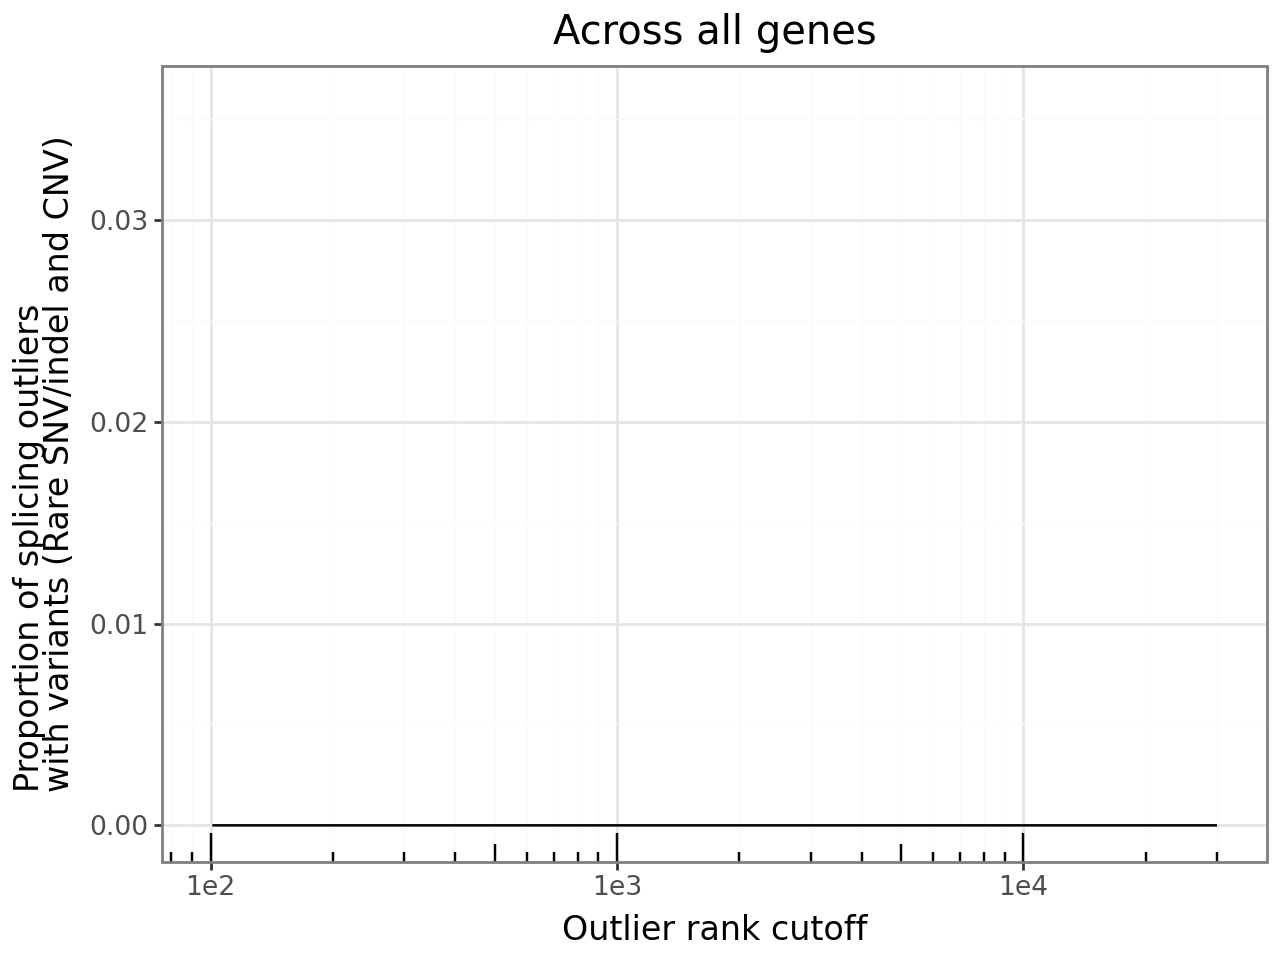

In [42]:



merged_vars = germline_snvs.merge(absplice_predisp, left_on=["chrom_x", "POS", "Ref", "Alt"], right_on=["chrom", "hg19_end", "ref", "alt"], how="left")
# merged_vars.loc[merged_vars["AbSplice2_max"].isna(), "AbSplice2_max"] = 0






merged_vars["germline_splicing"] = False
merged_vars.loc[(merged_vars["AbSplice2_max"] >= 0.2) | (merged_vars["Consequence"].isin(["splice_acceptor_variant", "splice_donor_variant"])) | (merged_vars["max_spliceai_score"] >= 0.2) , "germline_splicing"] = True


fr_res_annotated = fr_res.merge(merged_vars, left_on=["sampleID", "hgncSymbol"], right_on=["sampleID", "HUGO_Symbol"], how="left")

fr_res_annotated["somatic_splicing"] = False
fr_res_annotated.loc[(fr_res_annotated["somatic_snv_AbSplice2_max"] >= 0.2) | (fr_res_annotated["somatic_snv_Consequence"].isin(["splice_acceptor_variant", "splice_donor_variant"])) | (fr_res_annotated["somatic_snv_max_spliceai_score"] >= 0.2) , "somatic_splicing"] = True



fr_res_annotated["IMPACT"] = False
fr_res_annotated.loc[(fr_res_annotated["germline_splicing"] == True) | (fr_res_annotated["somatic_splicing"] == True), "IMPACT"] = True


print(sum(fr_res_annotated["germline_splicing"]))
print(sum(fr_res_annotated["somatic_splicing"]))

fr_res_annotated["CNV"] = "No CNV"

fr_res_annotated = fr_res_annotated.sort_values("pValue")

# %%

# %%

# %%
# pr_res_all = calculate_proportions(pr_res_all, expression_col="CNV")
fr_res_annotated = calculate_proportions(fr_res_annotated, expression_col="VEP", expression_directions = ["splicing"])


# %%


# protrider_auc_underexpression = get_auc_metrics(pr_res_all)

protrider_auc_overexpression = get_auc_metrics(fr_res_annotated, expression_direction="splicing")

# %%
print(fr_res_annotated.shape, "len protrider after adding proportions")

# %%
# p = plot_variant_proportions(
#     fr_res_annotated, protrider_auc_overexpression, plot_title="FRASER", expression_direction="splicing")
# p.save("/home/a379i/Scripts/AberrantSplicing/proportions_all_genes_underexpression_outliers.png", width=6, height=4, dpi=300)

# %%

plot_data = fr_res_annotated.copy()
expression_direction = "splicing"
p = ( pn.ggplot(plot_data[(plot_data["Method"] == "FRASER") & (plot_data[f"{expression_direction}_rank"] > 100) & 
                                    (plot_data[f"{expression_direction}_rank"] < 1e10)])
                
                # --- Line 1 (Deletion) ---
                # We map 'color' to a string label. Plotnine sees this as a category.
                + pn.geom_line(pn.aes(x=f"{expression_direction}_rank", 
                                    y=f"{expression_direction}_proportions_VEP", 
                                    )) 
                + pn.geom_ribbon(pn.aes(x=f"{expression_direction}_rank", 
                                        ymin=f"{expression_direction}_ci_min_VEP", ymax=f"{expression_direction}_ci_max_VEP"), 
                                alpha=0.2, outline_type='none')
                
            
                + pn.scale_x_log10()
                + pn.annotation_logticks(sides="b")
                + pn.labs(
                    y=f"Proportion of {expression_direction} outliers\nwith variants (Rare SNV/indel and CNV)",
                    x="Outlier rank cutoff",
                    title="Across all genes"
                )
                + pn.theme_bw(base_size=12)
    )


p




In [42]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")

fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
fr_res = pd.merge(fr_res, sa, left_on="sampleID", right_on="pid")




In [40]:
fr_res_new = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/ACC/results_gene_all.tsv", sep="\t")
# fr_res_new[(fr_res_new["padjust"] <= 0.05) & (fr_res_new["padjust_Genes_to_test_on_all_samples"].notna())]


/tmp/ipykernel_2463754/759831234.py:1: DtypeWarning: Columns (0: seqnames) have mixed types. Specify dtype option on import or set low_memory=False.


KeyError: 'padjust_Genes_to_test_on_all_samples'

In [19]:
fr_res_new[(fr_res_new["hgncSymbol"].isin(extended_dresden_list)) & (fr_res_new["padjust"] <= 0.05)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [41]:
fr_res_new[(fr_res_new["hgncSymbol"].isin(extended_dresden_list)) & (fr_res_new["padjust"] <= 0.05)]
fr_res_new[(fr_res_new["sampleID"] == "DSG19G") & (fr_res_new["hgncSymbol"] == "MTAP")]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [33]:
fr_res[(fr_res["Diag_x"] == "ACC") & (fr_res["hgncSymbol"].isin(extended_dresden_list)) & (fr_res["padjust"] <= 0.05)].sort_values("pValue")

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [11]:
sa[sa["Tumorzellgehalt (Bioinformatik)"] < 0.2]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [4]:
fr_predisp = fr_res[fr_res["hgncSymbol"].isin(extended_dresden_list)]
fr_samples = fr_predisp["sampleID"].unique()
len(fr_samples)

1923

In [ ]:
import polars as pl

snvs = (
    pl.scan_csv(
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/vep_res_rare_snv_all_aggregated.tsv", 
        separator="\t"
    )
    # 1. Broad filter ONLY for Gene and Sample first
    .filter(
        (pl.col("SYMBOL").is_in(extended_dresden_list)) & 
        (pl.col("sampleID").is_in(fr_samples))
    )
    # 2. Calculate score, but handle nulls so the code doesn't crash
    .with_columns(
        max_spliceai_score = pl.when(pl.col("SpliceAI_pred").is_not_null())
        .then(
            pl.col("SpliceAI_pred")
            .str.split("|")
            .list.slice(1, 4) 
            .list.eval(pl.element().cast(pl.Float64))
            .list.max()
        )
        .otherwise(pl.lit(0.0)) # Assign 0.0 if missing, so the filter can handle it
    )
    # 3. Now apply the OR logic
    .filter(
        (pl.col("max_spliceai_score") >= 0.2) | 
        (pl.col("IMPACT") == "HIGH") | 
        (pl.col("Consequence").str.contains("spl"))
    )
    .collect(engine="streaming")
)


In [ ]:
impact_map = {'HIGH': 4, 'MODERATE': 3, 'LOW': 2, 'MODIFIER': 1}
df_final = (
    snvs
    # 1. Map IMPACT to rank (using replace)
    .with_columns(
        impact_rank = pl.col("IMPACT").replace(impact_map, default=0).cast(pl.Int8)
    )
    # 2. Filter out missing Gene symbols
    .filter(pl.col("Gene") != "-")
    # 3. Sort (descending list must match columns list)
    .sort(
        by=['sampleID', 'Gene', '#Uploaded_variation', 'impact_rank'], 
        descending=[False, False, False, True]
    )
    # 4. Drop duplicates (keeping the first occurrence, which is the highest rank)
    .unique(
        subset=['sampleID', 'Gene', '#Uploaded_variation'], 
        keep="first"
    )
)

df_final.write_csv(
    "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_snvs.tsv", 
    separator="\t"
)

In [ ]:
import polars as pl

indels = (
    pl.scan_csv(
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/vep_res_rare_indel_all_aggregated.tsv", 
        separator="\t"
    )
    # 1. Broad filter ONLY for Gene and Sample first
    .filter(
        (pl.col("SYMBOL").is_in(extended_dresden_list)) & 
        (pl.col("sampleID").is_in(fr_samples))
    )
    # 2. Calculate score, but handle nulls so the code doesn't crash
    .with_columns(
        max_spliceai_score = pl.when(pl.col("SpliceAI_pred").is_not_null())
        .then(
            pl.col("SpliceAI_pred")
            .str.split("|")
            .list.slice(1, 4) 
            .list.eval(pl.element().cast(pl.Float64))
            .list.max()
        )
        .otherwise(pl.lit(0.0)) # Assign 0.0 if missing, so the filter can handle it
    )
    # 3. Now apply the OR logic
    .filter(
        (pl.col("max_spliceai_score") >= 0.2) | 
        (pl.col("IMPACT") == "HIGH") | 
        (pl.col("Consequence").str.contains("spl"))
    )
    .collect(engine="streaming")
)

df_final_indels = (
    indels
    # 1. Map IMPACT to rank (using replace)
    .with_columns(
        impact_rank = pl.col("IMPACT").replace(impact_map, default=0).cast(pl.Int8)
    )
    # 2. Filter out missing Gene symbols
    .filter(pl.col("Gene") != "-")
    # 3. Sort (descending list must match columns list)
    .sort(
        by=['sampleID', 'Gene', '#Uploaded_variation', 'impact_rank'], 
        descending=[False, False, False, True]
    )
    # 4. Drop duplicates (keeping the first occurrence, which is the highest rank)
    .unique(
        subset=['sampleID', 'Gene', '#Uploaded_variation'], 
        keep="first"
    )
)

df_final_indels = df_final_indels.drop("")
df_final_indels.write_csv(
    "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_indels.tsv", 
    separator="\t"
)


## check how manny high intron varinats

In [5]:
df_final = pl.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_snvs.tsv", separator="\t")

df_final_indels = pl.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_indels.tsv", separator="\t")


df_final = df_final.with_columns(type = pl.lit("snv"))
df_final_indels = df_final_indels.with_columns(type = pl.lit("indel"))

# Now use the "relaxed" concat to handle the SchemaError you had earlier
all_vars = pl.concat([df_final, df_final_indels], how="diagonal_relaxed")


In [6]:
all_vars.filter(pl.col("max_spliceai_score") >= 0.2)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [73]:
all_vars.write_csv(
    "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/predisp/predisp_splicing_all_vars.tsv", 
    separator="\t"
)

In [11]:
all_vars.filter((pl.col("max_spliceai_score") >= 0.2) | (pl.col("Consequence").str.contains("splice_acceptor_variant")) | 
                (pl.col("Consequence").str.contains("splice_donor_variant")))

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [7]:
all_vars = all_vars.to_pandas()
all_vars["start"] = all_vars["Location"].str.split(":").str[1]
all_vars["chrom"] = all_vars["Location"].str.split(":").str[0]



In [60]:
all_vars.shape

(9955, 29)

In [99]:
valid_positions = (
    all_vars[all_vars["type"] == "snv"]["start"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)
absplice_predisp = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_max_abSplice_snvs_hg19.parquet")
        .filter((pl.col("hg19_start").is_in(valid_positions)) | (pl.col("hg19_start").is_in(valid_positions)))
        # .filter(pl.col("score_category") == "high")
        # .filter(pl.col("start") == 1220371)
        .collect(engine="streaming")
      ).to_pandas()

absplice_predisp['chrom'] = absplice_predisp["chrom"].str.split("chr").str[1]
absplice_predisp = absplice_predisp[["score_category", "hg19_chrom", "hg19_start", "hg19_end", "AbSplice2_max", "pangolin_score", "chrom", "start", "end", "ref", "alt", "gene_id"]]

In [96]:
absplice_predisp.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [102]:
all_vars = all_vars.merge(absplice_predisp, left_on=["chrom", "start", "Allele"], right_on = ["chrom", "hg19_start", "alt"], how="left")


In [104]:
fr_res_vars = fr_predisp.merge(all_vars, left_on=["sampleID", "hgncSymbol"], right_on=["sampleID", "SYMBOL"])

In [7]:
duplicates = fr_res_vars.duplicated(subset=["sampleID", "geneID"])
fr_res_vars[duplicates]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [105]:
fr_predisp[fr_predisp["IMPACT"].notna()]
fr_predisp[(fr_predisp["IMPACT"].notna()) & 
           ((fr_predisp["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
            (fr_predisp["ANNOTATION_control_indel"].str.contains("germline", na=False)))]

c = fr_res_vars[(fr_res_vars["IMPACT_x"].notna()) & 
           ((fr_res_vars["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
            (fr_res_vars["ANNOTATION_control_indel"].str.contains("germline", na=False)))]
c["sampleID"].value_counts()
#c[c["IMPACT_y"] != "HIGH"] # non-canonical


# c[(c["IMPACT_y"] != "HIGH")]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [116]:
# c = pd.merge(c, sa, left_on="sampleID", right_on="pid")

c[(c["IMPACT_y"] != "HIGH") & (c["Consequence"].str.contains("intron_variant")) & (c["max_spliceai_score"] >= 0.2)][["sampleID", "AF", "Consequence", "SYMBOL", "IMPACT_y", "start", "end_x", "deltaPsi",  "max_spliceai_score", "potentialImpact", "AbSplice2_max", "pangolin_score", "score_category", "chrom", "Location", "padjust"]].sort_values("AbSplice2_max",)




Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [13]:
c[c["sampleID"] == "DNATQ4"]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
